In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Data Exploration

In [48]:
df = pd.read_csv("E:\Projects\Customer-Churn-Prediction\dataset\Customer-Churn-Dataset.csv")
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2411,6901-GOGZG,Male,0,No,Yes,60,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,84.95,4984.85,No
2753,6857-VWJDT,Female,0,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Mailed check,95.65,95.65,Yes
1463,4763-PGDPO,Female,0,No,No,4,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Electronic check,70.40,281,Yes
2794,5353-WILCI,Female,0,No,No,28,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,No,Electronic check,56.05,1522.65,No
191,2472-OVKUP,Male,0,Yes,No,6,Yes,No,Fiber optic,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,91.00,531,Yes


In [49]:
## Looks like the customerID is of no use, hence its good to remove all those data that won't add meaning to train the model.
df.drop("customerID", axis="columns", inplace=True)
df.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4458,Male,0,Yes,Yes,38,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,No,Month-to-month,Yes,Electronic check,94.65,3624.3,Yes
4872,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),84.90,6065.3,No
2305,Male,0,Yes,Yes,34,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),97.70,3410,No
473,Male,0,Yes,No,24,Yes,No,DSL,Yes,No,No,Yes,No,No,Month-to-month,No,Mailed check,53.60,1315.35,No
6473,Female,0,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,94.40,94.4,Yes


In [50]:
df.shape

(7043, 20)

In [51]:
#Check if all datatypes are consistent
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [52]:
df.TotalCharges.values
#If we look at column 'MonthlyCharges' its float while 'TotalCharges' is object (string). This is inconsistent. We need to convert
#object dtype to float  
(df["TotalCharges"].isna() | df["TotalCharges"].isna() | (df["TotalCharges"].str.strip() == "")).sum()

np.int64(11)

In [53]:
df[df["TotalCharges"].isna() | df["TotalCharges"].isna() | (df["TotalCharges"].str.strip() == "")]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [54]:
df = df[~(df["TotalCharges"].isna() | df["TotalCharges"].isna() | (df["TotalCharges"].str.strip() == ""))]
df.shape

(7032, 20)

In [55]:
df.TotalCharges = pd.to_numeric(df.TotalCharges)
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

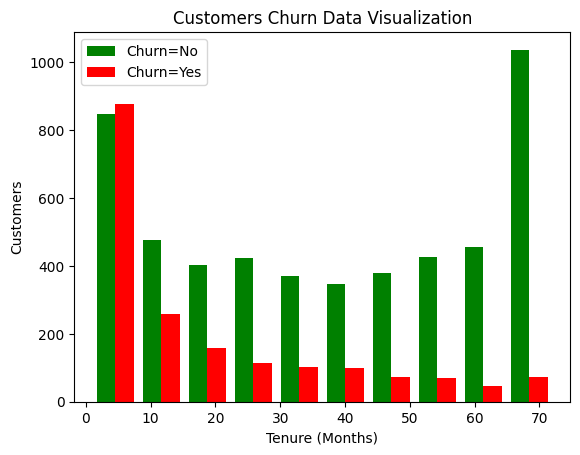

In [64]:
# Lets see how many customers left (churn=="Yes") and how many stayed (churn=="No") : Based on Tenure
tenure_churn_no = df[df.Churn == "No"].tenure
tenure_churn_yes = df[df.Churn == "Yes"].tenure
plt.xlabel("Tenure (Months)")
plt.ylabel("Customers")
plt.title("Customers Churn Data Visualization")
plt.hist([tenure_churn_no, tenure_churn_yes],  color=["green", "red"], label=["Churn=No", "Churn=Yes"])
plt.legend()

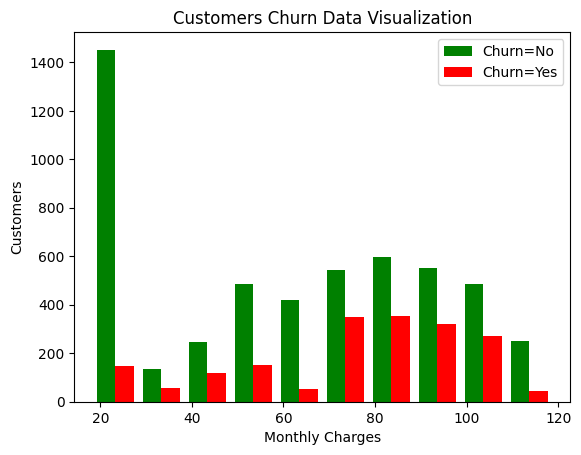

In [65]:
# Lets see how many customers left (churn =="Yes") and how many stayed (churn =="No") : Based on MonthlyCharges
monthlyCharges_churn_no = df[df.Churn == "No"].MonthlyCharges
monthlyCharges_churn_yes = df[df.Churn == "Yes"].MonthlyCharges 
plt.xlabel("Monthly Charges")
plt.ylabel("Customers")
plt.title("Customers Churn Data Visualization")
plt.hist([monthlyCharges_churn_no, monthlyCharges_churn_yes],  color=["green", "red"], label=["Churn=No", "Churn=Yes"])
plt.legend()